In [130]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

## LIBRARY

#### Kode tersebut merupakan kode untuk mengimport library yang dibutuhkan, seperti OpenCV, Matplotlib.pyplot, dan NumPy:
- Library OpenCV digunakan untuk melakukan berbagai operasi citra seperti membaca, menampilkan, memproses, dan memodifikasi, namun pada jurnal kali ini hanya digunakan untuk membaca dan mengubah citra menjadi grayscale.
- NumPy digunakan untuk representasi citra dalam bentuk matriks array, dan pada jurnal kali ini digunakan untuk melalukan operasi pada matriks dan manipulasi piksel.
- Matplotlib digunakan untuk menampilkan citra hasil pemrosesan berbagai tahap proses

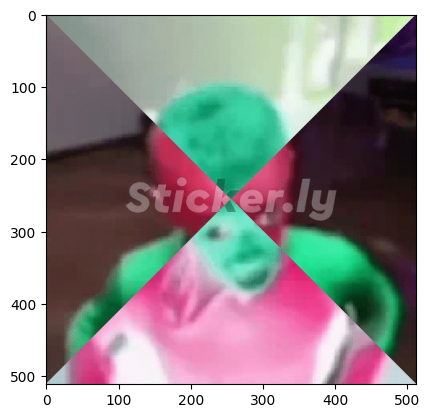

In [131]:
robby = cv.imread('Assets/robby_negatif.jpg')
robbyRGB = cv.cvtColor(robby, cv.COLOR_BGR2RGB)

plt.imshow(robbyRGB)

#### Membaca Gambar dan Mengubahnya Menjadi RGB kemudian Menampilkannya

Membaca citra dengan menggunakan `cv.imread` dan mengubah citra tersebut ke RGB dengan menggunakan `cv.cvtColor(, cv.COLOR_BGR2RGB)` menampilkannya menggunakan `plt.imshow`.

Text(0.5, 1.0, 'Segitiga Kanan')

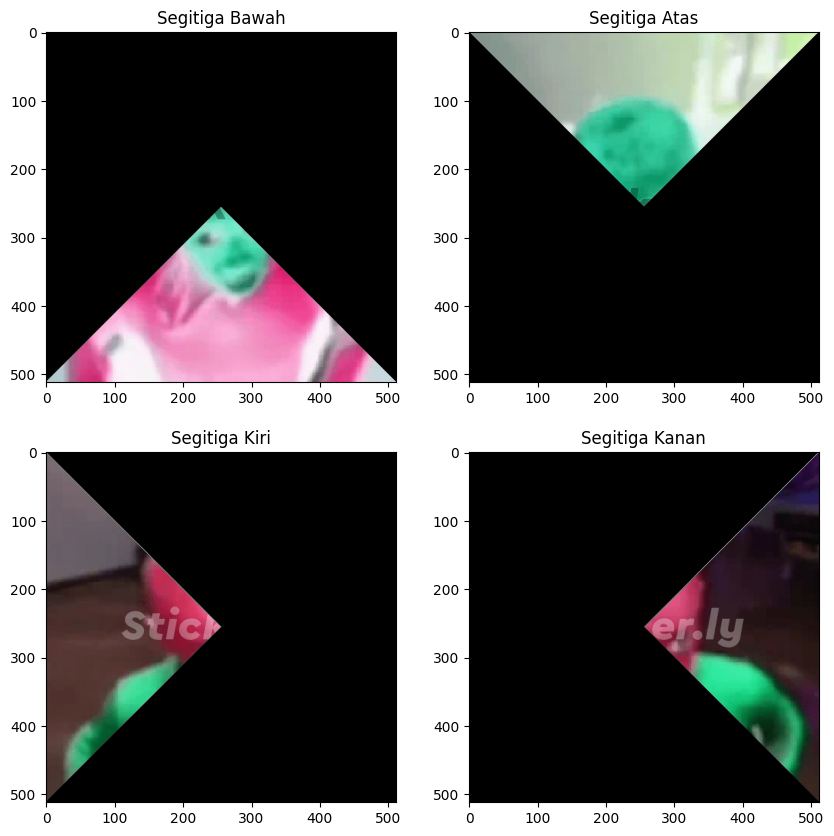

In [132]:
def crop_diagonal(image):
    height, width = image.shape[:2]
    bawah = np.zeros_like(image)
    atas = np.zeros_like(image)
    kiri = np.zeros_like(image)
    kanan = np.zeros_like(image)
    

    for i in range(height):
        for j in range(width):
            diagonal_utama = i < j
            diagonal_anti  = i < (height - j - 1)

            if diagonal_utama and diagonal_anti:
                atas[i, j]  = image[i, j]
            elif (not diagonal_utama) and (not diagonal_anti):
                bawah[i, j] = image[i, j]
            elif (not diagonal_utama) and diagonal_anti:
                kiri[i, j]  = image[i, j]
            else:
                kanan[i, j] = image[i, j]

    return bawah, atas, kiri, kanan

r_bawah, r_atas, r_kiri, r_kanan = crop_diagonal(robbyRGB)

plt.figure (figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.imshow(r_bawah)
plt.title("Segitiga Bawah")

plt.subplot(2, 2, 2)
plt.imshow(r_atas)
plt.title("Segitiga Atas")

plt.subplot(2, 2, 3)
plt.imshow(r_kiri)
plt.title("Segitiga Kiri")

plt.subplot(2, 2, 4)
plt.imshow(r_kanan)
plt.title("Segitiga Kanan")


#### Memotong Citra Secara Diagonal kemudian Menampilkannya

Memotong citra dengan cara diagonal menggunakan fungsi `crop_diagonal()`, di mana setiap piksel diklasifikasikan ke dalam salah satu dari empat segitiga berdasarkan posisinya terhadap diagonal utama dan diagonal anti. Diagonal utama dicek dengan kondisi `i < j`, sedangkan diagonal anti dicek dengan kondisi `i < (height - j - 1)`. Berdasarkan kombinasi kedua kondisi tersebut, setiap piksel dialokasikan ke segitiga atas (keduanya terpenuhi), segitiga bawah (keduanya tidak terpenuhi), segitiga kiri (hanya diagonal anti terpenuhi), atau segitiga kanan (hanya diagonal utama terpenuhi). Kemudian menampilkan keempat hasil potongan segitiga tersebut menggunakan `plt.imshow()`.

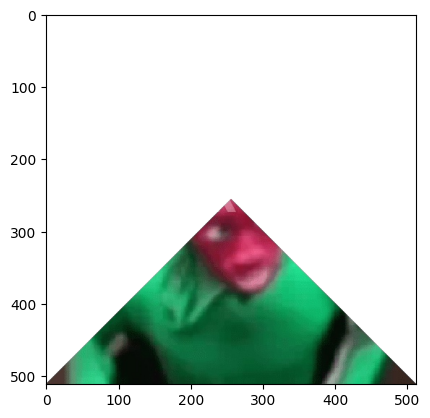

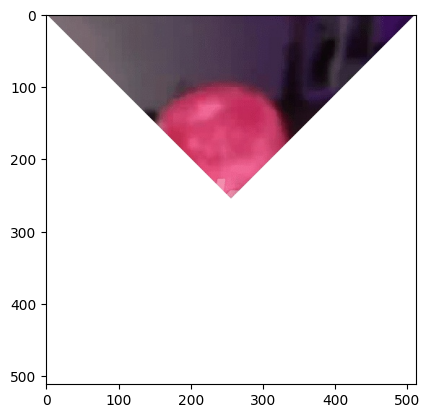

In [133]:
r_bawahB = 255 - r_bawah
r_atasB = 255 - r_atas

plt.imshow(r_bawahB)
plt.show()

plt.imshow(r_atasB)
plt.show()


#### Mengubah Segitiga Atas dan Bawah nya menjadi Negatif kemudian menampilkannya

Mengubah warna pada hasil potongan segitiga bawah dan segitiga atas dengan cara mengurangkan nilai piksel dari `255`, sehingga `r_bawahB = 255 - r_bawah` dan `r_atasB = 255 - r_atas`. Operasi ini membalik setiap nilai piksel sehingga warna terang menjadi gelap dan sebaliknya. Kemudian menampilkan kedua hasil inversi tersebut menggunakan `plt.imshow()`.

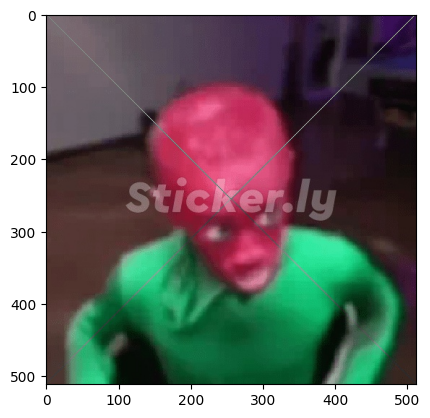

In [134]:
def merge_diagonal(atas, bawah, kiri, kanan):
    h, w = atas.shape[:2]
    hasil = np.zeros_like(atas)

    for i in range(h):
        for j in range(w):
            diagonal_utama = i < j
            diagonal_anti  = i < (h - j - 1)

            if diagonal_utama and diagonal_anti:
                hasil[i, j] = atas[i, j]
            elif (not diagonal_utama) and (not diagonal_anti):
                hasil[i, j] = bawah[i, j]
            elif (not diagonal_utama) and diagonal_anti:
                hasil[i, j] = kiri[i, j]
            else:
                hasil[i, j] = kanan[i, j]

    return hasil

robby_baru = merge_diagonal(r_atasB, r_bawahB, r_kiri, r_kanan)

plt.imshow(robby_baru)

#### Menggabungkan Kembali Keempat Segitiga Menjadi Satu Citra Utuh

Menggabungkan kembali keempat segitiga yang telah diproses sebelumnya menggunakan fungsi `merge_diagonal()`, di mana fungsi ini bekerja dengan cara kebalikan dari `crop_diagonal()`. Setiap piksel pada citra hasil dialokasikan dari segitiga yang sesuai berdasarkan posisinya terhadap diagonal utama dan diagonal anti, dengan kondisi pengecekan yang sama yaitu `i < j` untuk diagonal utama dan `i < (h - j - 1)` untuk diagonal anti. Piksel yang berada di segitiga atas diambil dari parameter `atas`, segitiga bawah dari parameter `bawah`, segitiga kiri dari parameter `kiri`, dan segitiga kanan dari parameter `kanan`. Pada pemanggilan fungsi ini, segitiga atas dan bawah yang digunakan adalah versi yang telah diinversi yaitu `r_atasB` dan `r_bawahB`, sedangkan segitiga kiri dan kanan tetap menggunakan hasil potongan asli yaitu `r_kiri` dan `r_kanan`. Hasilnya disimpan dalam variabel `robby_baru` yang merupakan citra baru dengan kombinasi segitiga atas dan bawah yang telah terinversi warnanya, sementara segitiga kiri dan kanan tetap mempertahankan warna aslinya. Kemudian menampilkan citra gabungan tersebut menggunakan `plt.imshow()`.

Text(0.5, 1.0, 'Setelah Ekualisasi')

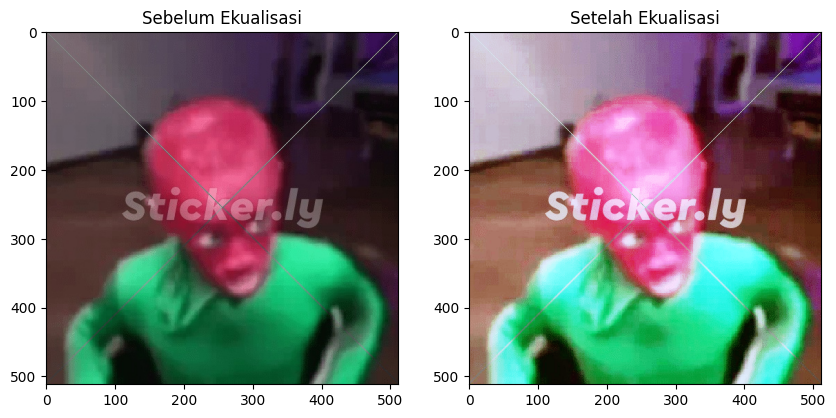

In [135]:
def ekualisasi(citra):
    height, width = citra.shape[:2]
    hist = np.zeros(256, dtype=int)

    for i in range(height):
        for j in range(width):
            hist[citra[i, j]] += 1

    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]

    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)
    hasil = np.zeros_like(citra, dtype=np.uint8)

    for i in range(height):
        for j in range(width):
            hasil[i, j] = cdf_normal[citra[i, j]]
    
    return hasil

def ekualisasi_rgb(citra):
    hasil = citra.copy()
    hasil[:, :, 0] = ekualisasi(citra[:, :, 0])
    hasil[:, :, 1] = ekualisasi(citra[:, :, 1])
    hasil[:, :, 2] = ekualisasi(citra[:, :, 2])
    return hasil

robbyE = ekualisasi_rgb(robby_baru)

plt.figure(figsize=(10, 10))

plt.subplot(1, 2, 1)
plt.imshow(robby_baru)
plt.title("Sebelum Ekualisasi")

plt.subplot(1, 2, 2)
plt.imshow(robbyE)
plt.title("Setelah Ekualisasi")


#### Melakukan Ekualisasi Histogram pada Citra RGB

Melakukan ekualisasi histogram pada citra `robby_baru` menggunakan dua fungsi yaitu `ekualisasi()` untuk satu channel dan `ekualisasi_rgb()` untuk keseluruhan channel RGB. Fungsi `ekualisasi()` bekerja dengan beberapa tahap, pertama menghitung histogram dari citra grayscale dengan cara menghitung frekuensi kemunculan setiap nilai piksel dari 0 hingga 255 menggunakan perulangan pada setiap piksel dan menyimpannya pada array `hist`. Setelah histogram terbentuk, dihitung nilai Cumulative Distribution Function (CDF) yaitu akumulasi dari nilai histogram secara berurutan mulai dari intensitas 0 hingga 255, sehingga `cdf[i]` menyimpan total piksel dengan nilai intensitas dari 0 sampai `i`. Selanjutnya CDF tersebut dinormalisasi dengan rumus `cdf * 255 / (height * width)` kemudian dibulatkan menggunakan `np.round()` dan dikonversi ke tipe `uint8`, sehingga menghasilkan pemetaan baru dari setiap nilai intensitas lama ke nilai intensitas baru yang lebih merata. Terakhir, setiap piksel pada citra dipetakan ulang nilainya menggunakan pemetaan `cdf_normal` tersebut sehingga distribusi intensitas pada citra menjadi lebih merata dan kontras citra meningkat. Sementara itu fungsi `ekualisasi_rgb()` menerapkan fungsi `ekualisasi()` secara terpisah pada masing-masing channel warna yaitu channel merah `[:, :, 0]`, channel hijau `[:, :, 1]`, dan channel biru `[:, :, 2]`, sehingga ekualisasi histogram dilakukan secara independen pada setiap channel tanpa saling mempengaruhi. Hasil ekualisasi disimpan dalam variabel `robbyE` kemudian ditampilkan secara berdampingan dengan citra sebelum ekualisasi menggunakan `plt.imshow()` untuk memperlihatkan perbedaan kontras antara citra sebelum dan sesudah ekualisasi histogram diterapkan.

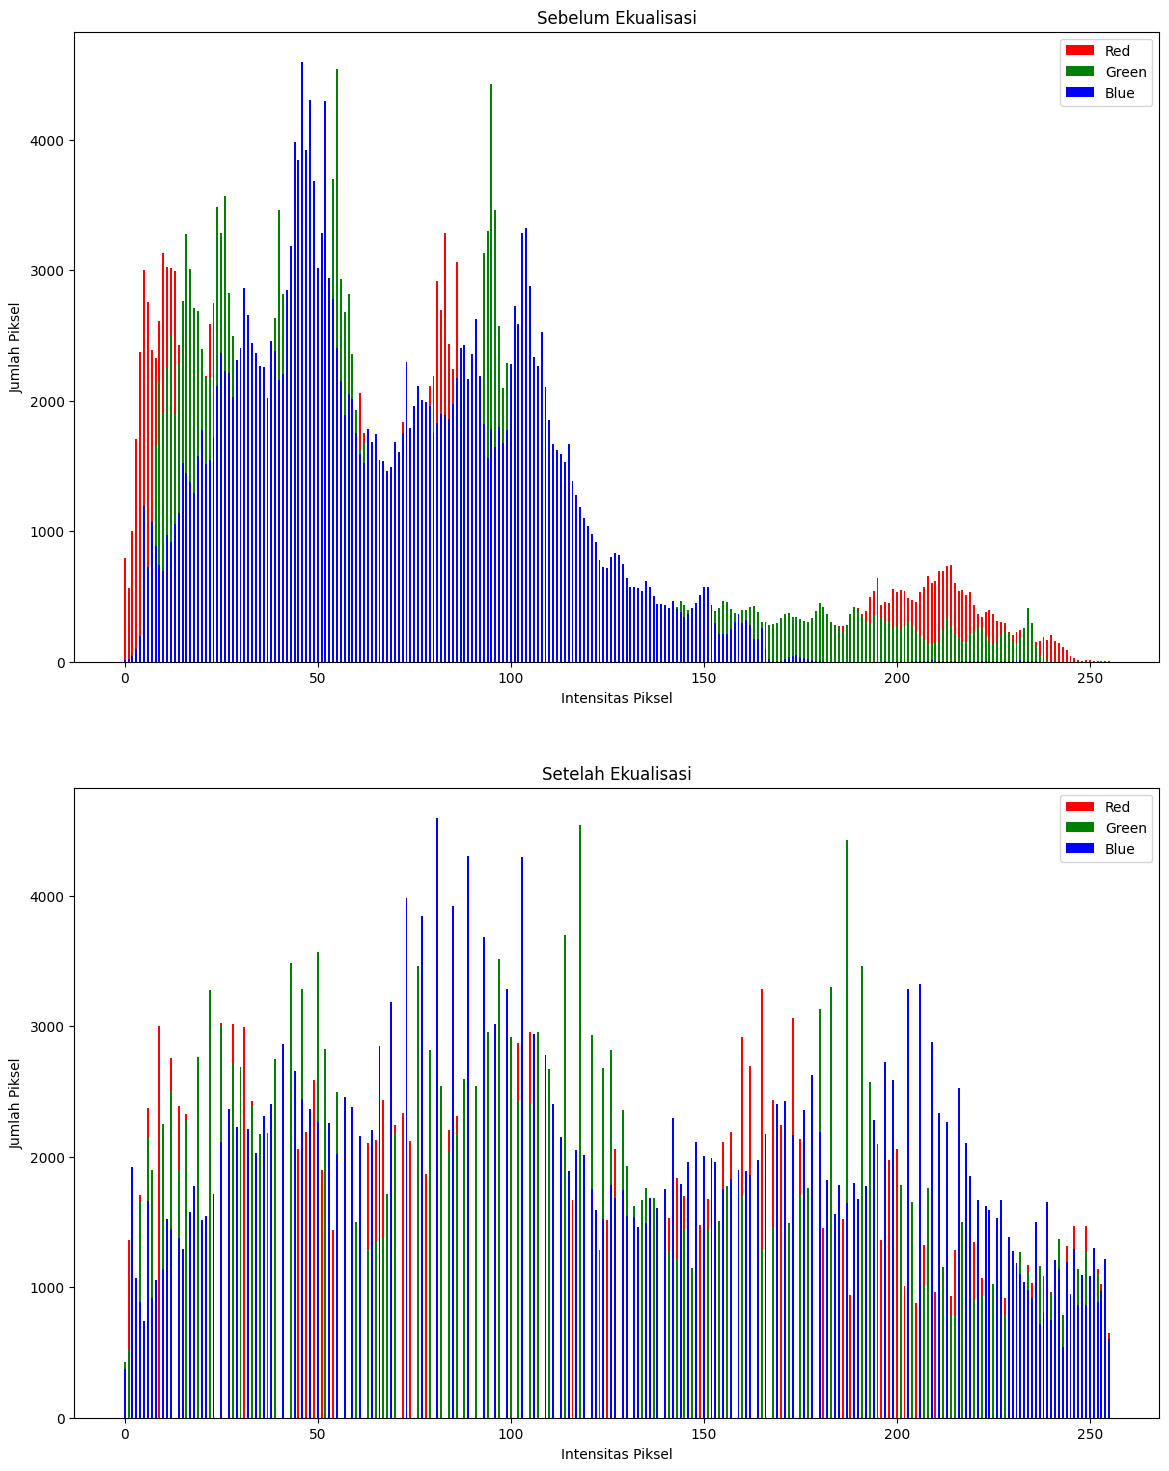

In [136]:
def buat_hist(citra): 
    histogram = [0] * 256 
 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1   
 
    return histogram 

plt.figure(figsize=(14, 18))

plt.subplot(2, 1, 1)
hist_rr = buat_hist(robby_baru[:, :, 0])
hist_rg = buat_hist(robby_baru[:, :, 1])
hist_rb = buat_hist(robby_baru[:, :, 2])

plt.xlabel("Intensitas Piksel")
plt.title("Sebelum Ekualisasi")
plt.ylabel("Jumlah Piksel")
plt.bar(range(256), hist_rr, color='red', width=0.5, label = "Red")
plt.bar(range(256), hist_rg, color='green', width=0.5, label = "Green")
plt.bar(range(256), hist_rb, color='blue', width=0.5, label = "Blue")

plt.legend()

hist_rr = buat_hist(robbyE[:, :, 0])
hist_rg = buat_hist(robbyE[:, :, 1])
hist_rb = buat_hist(robbyE[:, :, 2])

plt.subplot(2, 1, 2)
plt.xlabel("Intensitas Piksel")
plt.title("Setelah Ekualisasi")
plt.ylabel("Jumlah Piksel")
plt.bar(range(256), hist_rr, color='red', width=0.5, label = "Red")
plt.bar(range(256), hist_rg, color='green', width=0.5, label = "Green")
plt.bar(range(256), hist_rb, color='blue', width=0.5, label = "Blue")

plt.legend()

#### Menampilkan Histogram RGB Sebelum dan Sesudah Ekualisasi

Menampilkan perbandingan histogram dari setiap channel warna RGB pada citra sebelum dan sesudah ekualisasi menggunakan fungsi `buat_hist()` yang dibuat secara manual. Fungsi `buat_hist()` bekerja dengan cara menginisialisasi array histogram berisi 256 elemen bernilai nol yang merepresentasikan setiap kemungkinan nilai intensitas piksel dari 0 hingga 255, kemudian melakukan perulangan pada setiap piksel citra untuk menghitung frekuensi kemunculan setiap nilai intensitas dan menyimpannya pada indeks yang sesuai di dalam array histogram tersebut, sehingga pada akhirnya fungsi ini mengembalikan distribusi frekuensi intensitas piksel dari citra yang diberikan.

Histogram ditampilkan dalam dua subplot secara vertikal dengan ukuran figure `(14, 18)`. Pada subplot pertama, fungsi `buat_hist()` dipanggil secara terpisah untuk masing-masing channel merah `[:, :, 0]`, channel hijau `[:, :, 1]`, dan channel biru `[:, :, 2]` dari citra `robby_baru` yang belum diekualisasi, kemudian hasilnya ditampilkan sebagai bar chart dengan warna batang yang sesuai yaitu merah, hijau, dan biru menggunakan `plt.bar()` dengan lebar batang `0.5`. Pada subplot kedua, proses yang sama dilakukan pada citra `robbyE` yang telah melalui proses ekualisasi histogram. Kedua subplot dilengkapi dengan label sumbu x berupa `"Intensitas Piksel"`, label sumbu y berupa `"Jumlah Piksel"`, judul yang menjelaskan kondisi citra, serta legenda untuk membedakan ketiga channel warna. Dengan menampilkan kedua histogram secara berdampingan, dapat terlihat jelas perbedaan distribusi intensitas piksel sebelum dan sesudah ekualisasi, di mana histogram setelah ekualisasi diharapkan memiliki distribusi yang lebih merata dan menyebar di seluruh rentang nilai intensitas 0 hingga 255.

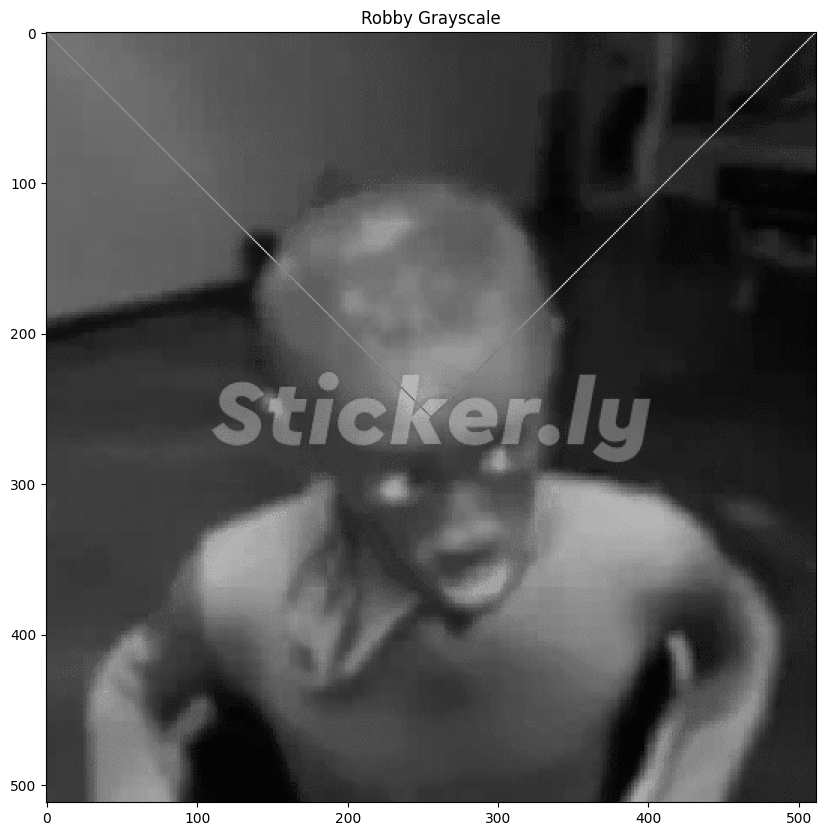

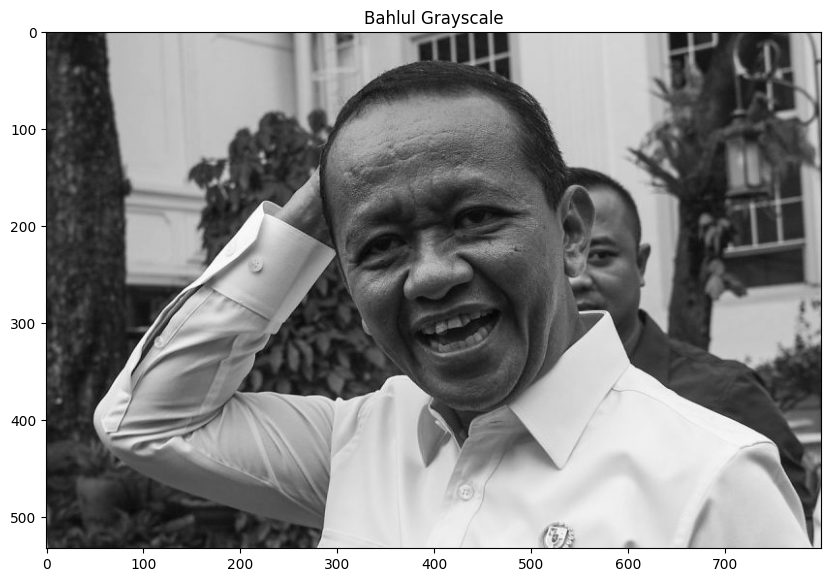

In [137]:
bahlul = cv.imread('Assets/bahlul.jpg')
bahlulG = cv.cvtColor(bahlul, cv.COLOR_BGR2GRAY)
robbyG = cv.cvtColor(robby_baru, cv.COLOR_RGB2GRAY)

plt.figure(figsize=(10, 10))
plt.title("Robby Grayscale")
plt.imshow(robbyG, cmap = 'gray')

plt.figure(figsize=(10, 10))
plt.title("Bahlul Grayscale")
plt.imshow(bahlulG, cmap = 'gray')

#### Mengkonversi Citra ke Grayscale dan Menampilkannya

Melakukan konversi dua citra ke dalam format grayscale untuk mempersiapkan proses pengolahan citra selanjutnya. Citra `bahlul` dibaca terlebih dahulu dari direktori `Assets/bahlul.jpg` menggunakan `cv.imread()` yang secara default membaca citra dalam format BGR, kemudian dikonversi ke grayscale menggunakan `cv.cvtColor()` dengan parameter `cv.COLOR_BGR2GRAY` dan disimpan dalam variabel `bahlulG`. Sementara itu, citra `robby_baru` yang sebelumnya telah melalui serangkaian proses pengolahan seperti pemotongan diagonal, inversi warna, dan penggabungan kembali, dikonversi ke grayscale menggunakan `cv.cvtColor()` dengan parameter `cv.COLOR_RGB2GRAY` karena citra tersebut tersimpan dalam format RGB, dan hasilnya disimpan dalam variabel `robbyG`. Perbedaan parameter konversi antara keduanya yaitu `COLOR_BGR2GRAY` dan `COLOR_RGB2GRAY` disebabkan oleh perbedaan urutan channel warna pada masing-masing citra. Kedua citra grayscale tersebut kemudian ditampilkan secara terpisah masing-masing dalam figure berukuran `(10, 10)` menggunakan `plt.imshow()` dengan parameter `cmap='gray'` agar citra ditampilkan dalam nuansa abu-abu dan bukan dalam colormap default matplotlib.

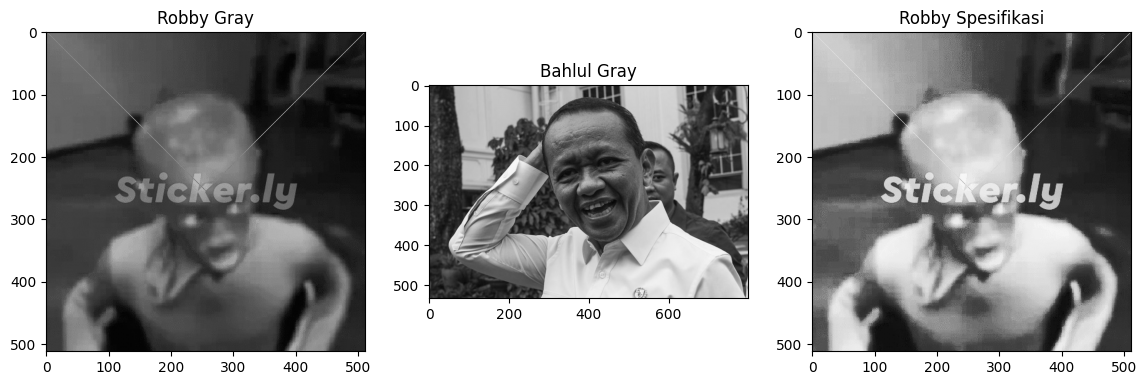

In [138]:
def spesifikasi_histogram(citra_asal, citra_target):
    hist_asal = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)

    for i in range(citra_asal.shape[0]):
        for j in range(citra_asal.shape[1]):
            hist_asal[citra_asal[i, j]] += 1

    for i in range(citra_target.shape[0]):
        for j in range(citra_target.shape[1]):
            hist_target[citra_target[i, j]] += 1

    cdf_asal = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)

    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]

    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i - 1] + hist_asal[i]
        cdf_target[i] = cdf_target[i - 1] + hist_target[i]

    cdf_asal = cdf_asal / cdf_asal[-1]
    cdf_target = cdf_target / cdf_target[-1]

    map_hist = np.zeros(256, dtype=np.uint8)

    for i in range(256):
        min_selisih = float('inf')
        best_j = 0
        for j in range(256):
            selisih = abs(cdf_asal[i] - cdf_target[j])
            if selisih < min_selisih:
                min_selisih = selisih
                best_j = j
        map_hist[i] = best_j

    height, width = citra_asal.shape
    hasil = np.zeros((height, width), dtype=np.uint8)

    for i in range(height):
        for j in range(width):
            hasil[i, j] = map_hist[citra_asal[i, j]]

    return hasil

robbyS = spesifikasi_histogram(robbyG, bahlulG)

plt.figure(figsize=(14, 10))

plt.subplot(1, 3, 1)
plt.title("Robby Gray")
plt.imshow(robbyG, cmap = 'gray')

plt.subplot(1, 3, 2)
plt.title("Bahlul Gray")
plt.imshow(bahlulG, cmap = 'gray')

plt.subplot(1, 3, 3)
plt.title("Robby Spesifikasi")
plt.imshow(robbyS, cmap = 'gray')


#### Melakukan Spesifikasi Histogram dan Menampilkan Hasilnya

Melakukan spesifikasi histogram yaitu proses pemetaan distribusi intensitas piksel dari citra asal agar menyerupai distribusi intensitas piksel dari citra target menggunakan fungsi `spesifikasi_histogram()`. Fungsi ini bekerja melalui beberapa tahap utama, pertama menghitung histogram dari kedua citra secara manual dengan cara menghitung frekuensi kemunculan setiap nilai intensitas piksel dari 0 hingga 255 pada `citra_asal` maupun `citra_target` dan menyimpannya masing-masing pada array `hist_asal` dan `hist_target`.

Setelah histogram terbentuk, dihitung nilai Cumulative Distribution Function (CDF) untuk kedua citra secara terpisah dengan cara mengakumulasikan nilai histogram secara berurutan dari intensitas 0 hingga 255, kemudian masing-masing CDF dinormalisasi dengan membaginya terhadap nilai CDF terakhir yaitu `cdf[-1]` yang merepresentasikan total keseluruhan piksel, sehingga nilai CDF yang dihasilkan berada pada rentang 0 hingga 1.

Selanjutnya dibuat pemetaan `map_hist` berukuran 256 elemen yang menghubungkan setiap nilai intensitas pada citra asal ke nilai intensitas baru yang paling sesuai pada citra target. Pemetaan ini dilakukan dengan cara mencari nilai `j` pada CDF target yang memiliki selisih paling kecil terhadap nilai CDF asal pada posisi `i` menggunakan perulangan sebanyak 256 iterasi untuk setiap nilai intensitas, sehingga distribusi intensitas citra asal dipetakan ulang agar semirip mungkin dengan distribusi intensitas citra target. Terakhir setiap piksel pada citra asal digantikan dengan nilai hasil pemetaan `map_hist` dan disimpan dalam array `hasil` bertipe `uint8`.

Fungsi tersebut kemudian dipanggil dengan `robbyG` sebagai citra asal dan `bahlulG` sebagai citra target, sehingga menghasilkan citra `robbyS` yaitu citra Robby dalam grayscale yang distribusi intensitas histogramnya telah disesuaikan mengikuti distribusi histogram dari citra Bahlul. Ketiga citra yaitu `robbyG`, `bahlulG`, dan `robbyS` kemudian ditampilkan secara berdampingan dalam satu figure berukuran `(14, 10)` menggunakan `plt.imshow()` dengan `cmap='gray'` untuk memperlihatkan perbandingan visual antara citra asal, citra target, dan citra hasil spesifikasi histogram.

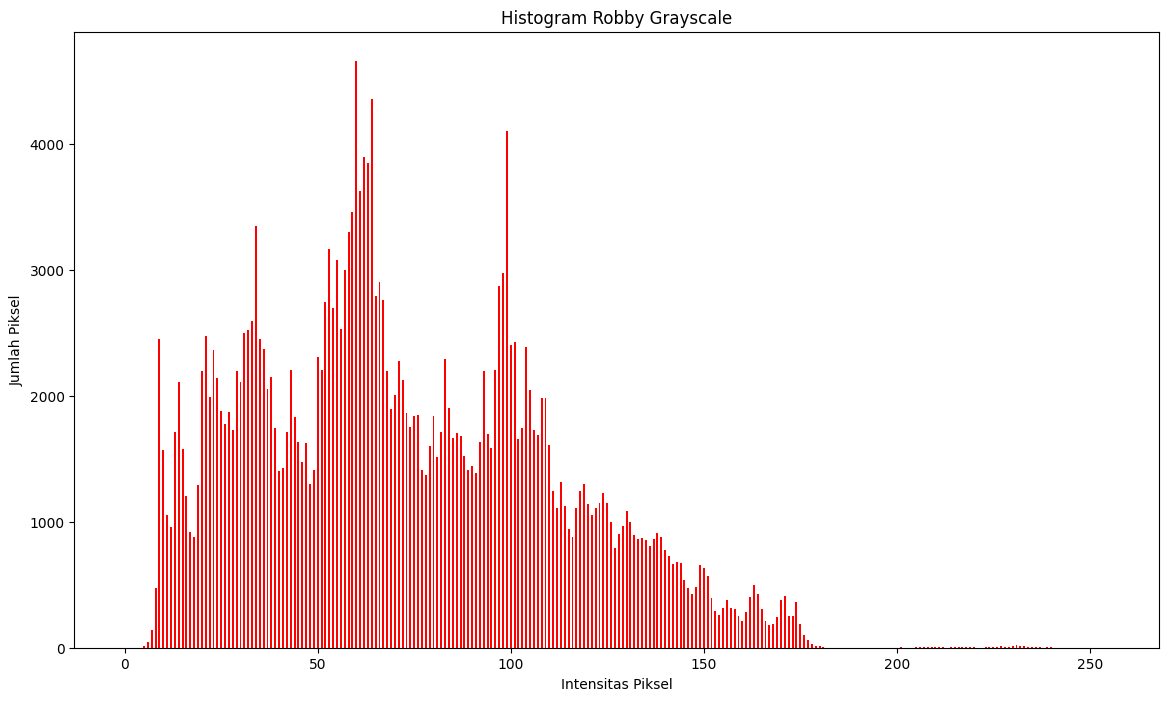

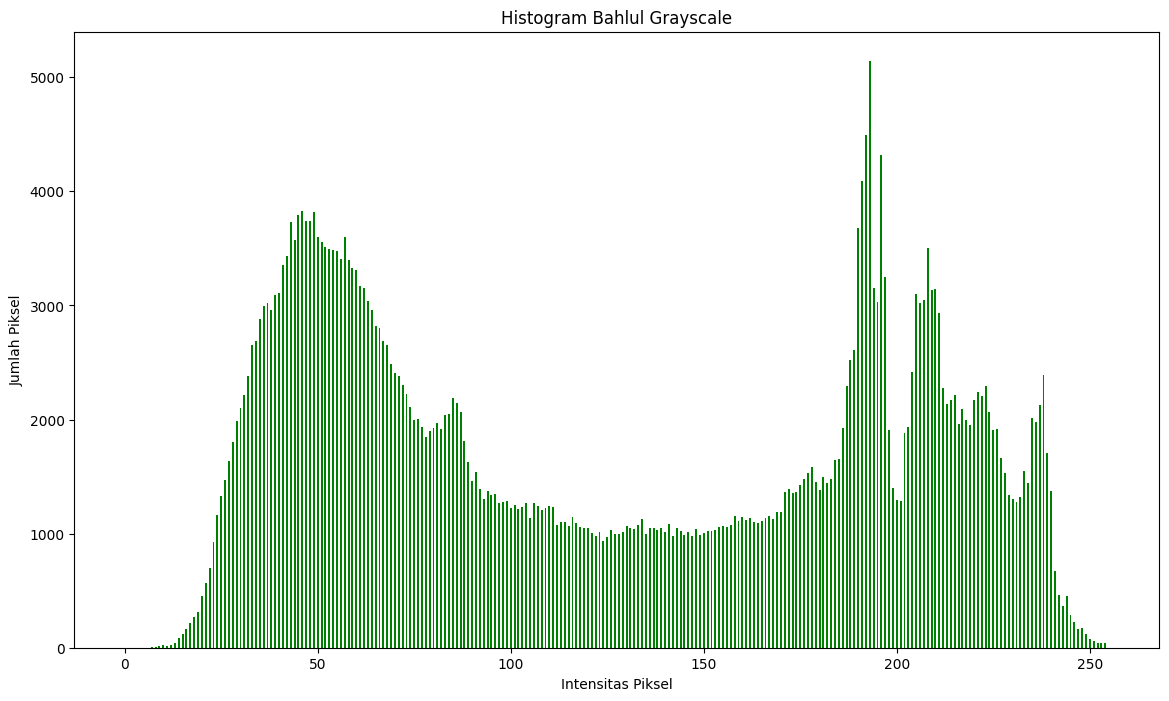

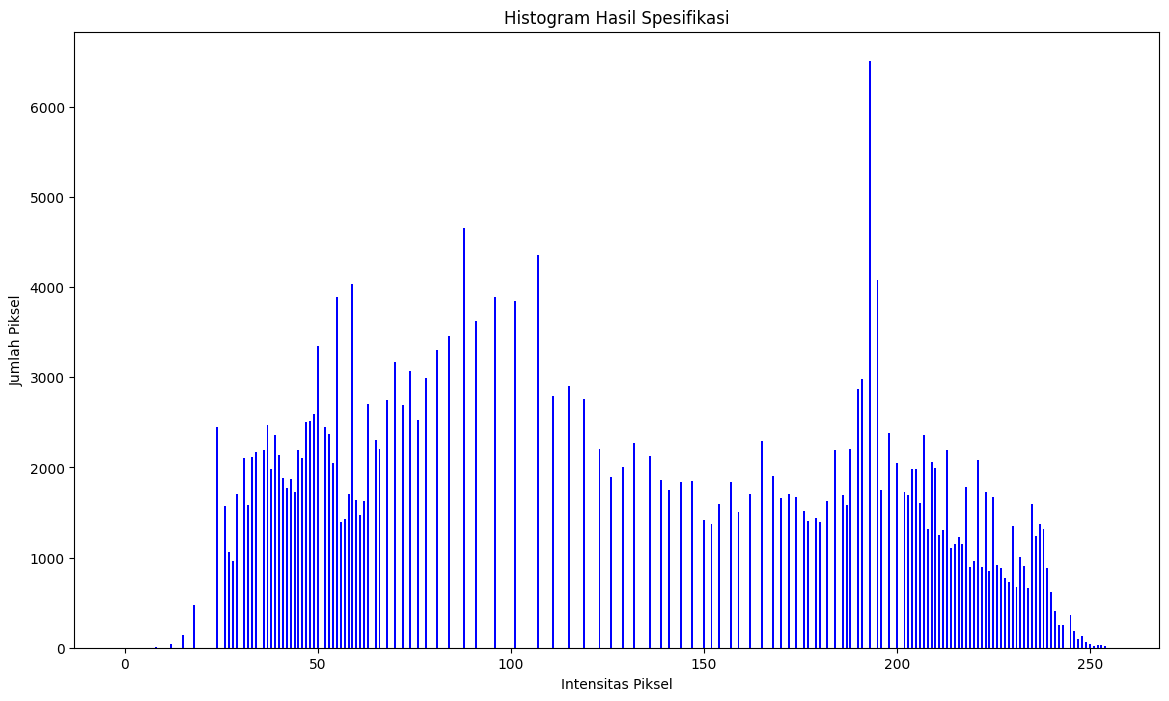

In [139]:
hist_r = buat_hist(robbyG)
hist_b = buat_hist(bahlulG)
hist_s = buat_hist(robbyS)

plt.figure(figsize=(14, 8))
plt.xlabel("Intensitas Piksel")
plt.title("Histogram Robby Grayscale")
plt.ylabel("Jumlah Piksel")
plt.bar(range(256), hist_r, color='red', width=0.5)
plt.show()

plt.figure(figsize=(14, 8))
plt.xlabel("Intensitas Piksel")
plt.title("Histogram Bahlul Grayscale")
plt.ylabel("Jumlah Piksel")
plt.bar(range(256), hist_b, color='green', width=0.5)
plt.show()

plt.figure(figsize=(14, 8))
plt.xlabel("Intensitas Piksel")
plt.title("Histogram Hasil Spesifikasi")
plt.ylabel("Jumlah Piksel")
plt.bar(range(256), hist_s, color='blue', width=0.5)
plt.show()

#### Menampilkan Histogram Grayscale dari Ketiga Citra Spesifikasi

Menampilkan histogram distribusi intensitas piksel dari ketiga citra grayscale secara terpisah untuk memverifikasi hasil spesifikasi histogram yang telah dilakukan sebelumnya. Histogram dari masing-masing citra dihitung terlebih dahulu menggunakan fungsi `buat_hist()` yang telah dibuat sebelumnya, di mana `hist_r` menyimpan histogram dari citra `robbyG`, `hist_b` menyimpan histogram dari citra `bahlulG`, dan `hist_s` menyimpan histogram dari citra `robbyS` hasil spesifikasi histogram.

Ketiga histogram tersebut kemudian ditampilkan masing-masing dalam figure terpisah berukuran `(14, 8)` menggunakan `plt.bar()` dengan lebar batang `0.5` dan warna yang berbeda-beda untuk membedakan ketiga citra, yaitu warna merah untuk histogram `robbyG`, warna hijau untuk histogram `bahlulG`, dan warna biru untuk histogram `robbyS`. Setiap figure dilengkapi dengan label sumbu x berupa `"Intensitas Piksel"`, label sumbu y berupa `"Jumlah Piksel"`, serta judul yang menjelaskan citra mana yang sedang ditampilkan histogramnya. Dengan menampilkan ketiga histogram secara terpisah, dapat diamati secara jelas bagaimana distribusi intensitas piksel pada citra `robbyS` hasil spesifikasi histogram memiliki pola yang lebih menyerupai distribusi histogram dari citra `bahlulG` sebagai citra target dibandingkan dengan distribusi histogram asli dari citra `robbyG`.